# Healthcare Disease Prediction
## Notebook 01 — Project Setup & Data Understanding

**Milestone:** establish a reproducible first-pass understanding of the Pima Indians Diabetes dataset before cleaning, feature engineering, or modeling.

This notebook answers:

1. What does each row and column represent?
2. Are types, ranges, duplicates, or missing-value conventions suspicious?
3. How balanced is the diabetes outcome?
4. What initial patterns deserve deeper investigation?

> **Responsible-use notice:** This is an educational research workflow, not a diagnostic system or certified medical device. The dataset represents adult women of Pima Indian heritage and must not be assumed to represent other populations. Model-derived risk is not a medical diagnosis.

### Dataset provenance

- **Dataset:** Pima Indians Diabetes Database
- **Original source:** National Institute of Diabetes and Digestive and Kidney Diseases; commonly distributed through the UCI/Kaggle ecosystem.
- **Local file:** `datasets/diabetes/pima_diabetes.csv`
- **Rows:** 768 observations
- **Target:** `Outcome` (`1` = diabetes outcome, `0` = no diabetes outcome)
- **Scope:** women aged at least 21 years from a specific population.

The local snapshot is checksum-pinned in `datasets/diabetes/SHA256SUMS`. We do not download data inside the notebook.

In [1]:
from pathlib import Path
import hashlib
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "datasets").exists():
    PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "datasets" / "diabetes" / "pima_diabetes.csv"
FIGURE_DIR = PROJECT_ROOT / "figures" / "notebook_01"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python:       {platform.python_version()}")
print(f"pandas:       {pd.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Dataset:      {DATA_PATH}")

Python:       3.12.7
pandas:       2.2.2
NumPy:        1.26.4
scikit-learn: 1.5.1
Dataset:      /Users/lingareddydhanushkumar/Desktop/Codex/ML/03_health_diseases_prediction_platform/datasets/diabetes/pima_diabetes.csv


## 1. Load the raw dataset

The raw CSV has no header row, so the documented feature names are supplied explicitly. No values are modified in this notebook.

In [2]:
COLUMNS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome",
]

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"
raw_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = pd.read_csv(DATA_PATH, names=COLUMNS)

print(f"SHA-256: {raw_sha256}")
print(f"Shape:   {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

SHA-256: 6bfe5d0f379d17a0e0819b996407e3c09bf80febd4287f2ed212190dfff154af
Shape:   768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


## 2. Data dictionary

| Feature | Meaning | Unit / coding | Initial expectation |
|---|---|---|---|
| `Pregnancies` | Number of pregnancies | count | non-negative integer |
| `Glucose` | 2-hour plasma glucose | mg/dL | zero is physiologically implausible |
| `BloodPressure` | Diastolic blood pressure | mmHg | zero is implausible |
| `SkinThickness` | Triceps skin-fold thickness | mm | zero likely encodes missingness |
| `Insulin` | 2-hour serum insulin | μU/mL | zero likely encodes missingness |
| `BMI` | Body mass index | kg/m² | zero is implausible |
| `DiabetesPedigreeFunction` | Family-history-derived score | unitless | positive continuous value |
| `Age` | Age | years | dataset scope begins at 21 |
| `Outcome` | Diabetes class | 0 or 1 | binary target |

These are dataset variables—not a complete clinical assessment. Important social, behavioral, longitudinal, and treatment factors are absent.

In [3]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "unique": df.nunique(),
    "minimum": df.min(),
    "maximum": df.max(),
})
schema

,dtype,non_null,null,unique,minimum,maximum
Pregnancies,int64,768,0,17,0.000,17.000
Glucose,int64,768,0,136,0.000,199.000
BloodPressure,int64,768,0,47,0.000,122.000
SkinThickness,int64,768,0,51,0.000,99.000
Insulin,int64,768,0,186,0.000,846.000
BMI,float64,768,0,248,0.000,67.100
DiabetesPedigreeFunction,float64,768,0,517,0.078,2.420
Age,int64,768,0,52,21.000,81.000
Outcome,int64,768,0,2,0.000,1.000


## 3. Structural quality checks

We distinguish literal nulls from **sentinel values**. A file may report zero missing values while still encoding unknown clinical measurements as `0`.

In [4]:
quality_checks = {
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "literal_missing_cells": int(df.isna().sum().sum()),
    "non_binary_target_values": int((~df["Outcome"].isin([0, 1])).sum()),
    "negative_numeric_cells": int((df.select_dtypes("number") < 0).sum().sum()),
}
pd.Series(quality_checks, name="count").to_frame()

,count
exact_duplicate_rows,0
literal_missing_cells,0
non_binary_target_values,0
negative_numeric_cells,0


In [5]:
zero_not_valid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_audit = pd.DataFrame({
    "zero_count": (df[zero_not_valid] == 0).sum(),
    "zero_percent": (df[zero_not_valid] == 0).mean().mul(100),
}).sort_values("zero_percent", ascending=False)
zero_audit

,zero_count,zero_percent
Insulin,374,48.698
SkinThickness,227,29.557
BloodPressure,35,4.557
BMI,11,1.432
Glucose,5,0.651


**Interpretation:** literal null counts alone are misleading here. Zeros in glucose, blood pressure, skin thickness, insulin, and BMI should be treated as candidate missing values during Notebook 02. They are retained untouched now so this notebook remains a faithful raw-data audit.

## 4. Descriptive statistics

Percentiles reveal scale, skew, and potential extreme values. They do not determine whether an observation is clinically invalid; those decisions require documented rules and domain review.

In [6]:
df.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Pregnancies,768.000,3.845,3.370,0.000,0.000,0.000,1.000,3.000,6.000,10.000,13.000,17.000
Glucose,768.000,120.895,31.973,0.000,57.000,79.000,99.000,117.000,140.250,181.000,196.000,199.000
BloodPressure,768.000,69.105,19.356,0.000,0.000,38.700,62.000,72.000,80.000,90.000,106.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,0.000,0.000,23.000,32.000,44.000,51.330,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,0.000,0.000,30.500,127.250,293.000,519.900,846.000
BMI,768.000,31.993,7.884,0.000,0.000,21.800,27.300,32.000,36.600,44.395,50.759,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.095,0.140,0.244,0.372,0.626,1.133,1.698,2.420
Age,768.000,33.241,11.760,21.000,21.000,21.000,24.000,29.000,41.000,58.000,67.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000


In [7]:
range_review = pd.DataFrame({
    "observed_min": df.drop(columns="Outcome").min(),
    "observed_max": df.drop(columns="Outcome").max(),
    "median": df.drop(columns="Outcome").median(),
    "skewness": df.drop(columns="Outcome").skew(),
}).sort_values("skewness", ascending=False)
range_review

,observed_min,observed_max,median,skewness
Insulin,0.000,846.000,30.500,2.272
DiabetesPedigreeFunction,0.078,2.420,0.372,1.920
Age,21.000,81.000,29.000,1.130
Pregnancies,0.000,17.000,3.000,0.902
Glucose,0.000,199.000,117.000,0.174
SkinThickness,0.000,99.000,23.000,0.109
BMI,0.000,67.100,32.000,-0.429
BloodPressure,0.000,122.000,72.000,-1.844


## 5. Target distribution

Class balance matters because accuracy can conceal poor detection of the positive class. Later notebooks will prioritize recall/sensitivity, specificity, PR-AUC, ROC-AUC, calibration, and clinically motivated thresholds.

In [8]:
target_summary = df["Outcome"].value_counts().rename(index={0: "No diabetes outcome", 1: "Diabetes outcome"}).to_frame("count")
target_summary["percent"] = target_summary["count"].div(len(df)).mul(100)
target_summary

,count,percent
Outcome,,
No diabetes outcome,500,65.104
Diabetes outcome,268,34.896


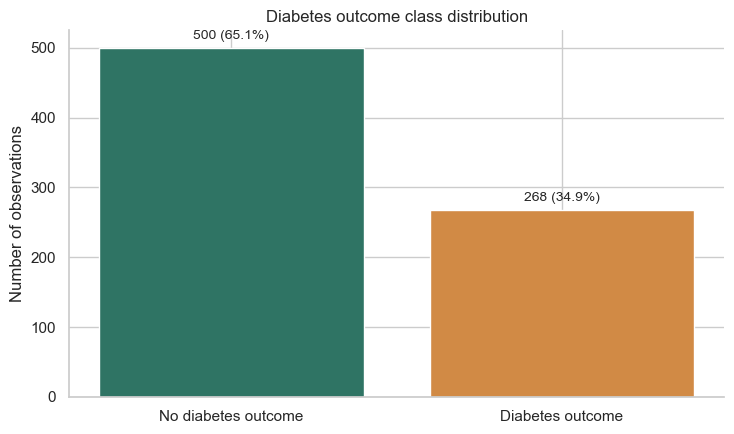

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
counts = df["Outcome"].value_counts().sort_index()
bars = ax.bar(["No diabetes outcome", "Diabetes outcome"], counts, color=["#2f7464", "#d18a45"])
ax.bar_label(bars, labels=[f"{n} ({n/len(df):.1%})" for n in counts], padding=4, fontsize=10)
ax.set(title="Diabetes outcome class distribution", ylabel="Number of observations", xlabel="")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Initial feature distributions

This compact view is a triage tool. Notebook 03 will perform rigorous univariate, bivariate, and multivariate analysis after missing-value semantics are handled.

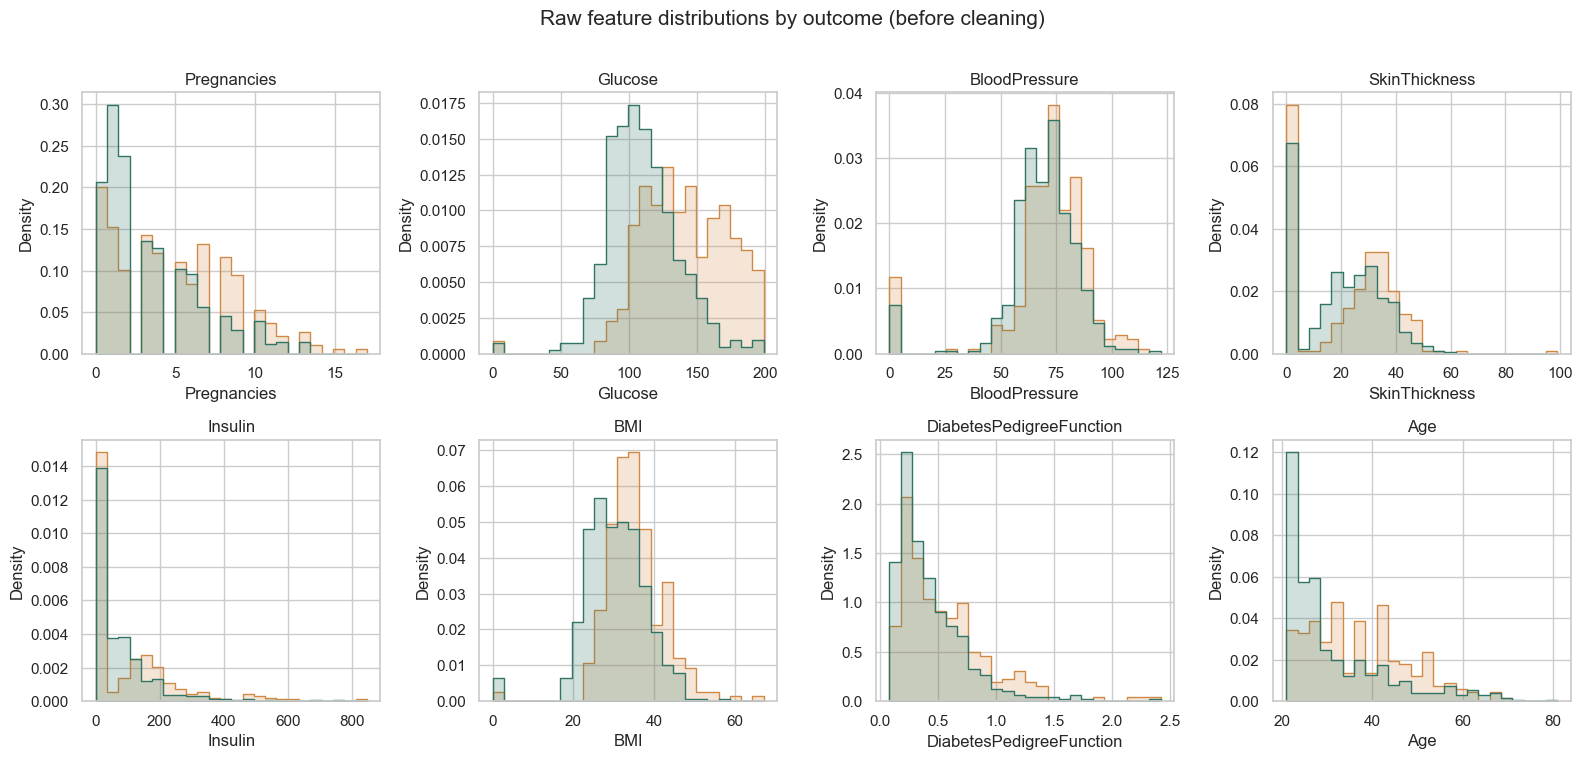

In [10]:
features = [c for c in COLUMNS if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for feature, ax in zip(features, axes.flat):
    sns.histplot(data=df, x=feature, hue="Outcome", bins=24, element="step", stat="density", common_norm=False, ax=ax, palette=["#2f7464", "#d18a45"], alpha=.22)
    ax.set_title(feature)
    ax.get_legend().remove() if ax.get_legend() else None
fig.suptitle("Raw feature distributions by outcome (before cleaning)", fontsize=15, y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "raw_feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Initial relationships with the target

The following differences are **associations in this dataset**, not causal effects and not proof that a variable should be used clinically.

In [11]:
group_comparison = df.groupby("Outcome")[features].agg(["mean", "median"]).T
group_comparison.columns = ["Outcome 0", "Outcome 1"]
group_comparison["absolute_difference"] = group_comparison["Outcome 1"] - group_comparison["Outcome 0"]
group_comparison

Outcome 0  Outcome 1  absolute_difference
Pregnancies              mean        3.298      4.866                1.568
                         median      2.000      4.000                2.000
Glucose                  mean      109.980    141.257               31.277
                         median    107.000    140.000               33.000
BloodPressure            mean       68.184     70.825                2.641
                         median     70.000     74.000                4.000
SkinThickness            mean       19.664     22.164                2.500
                         median     21.000     27.000                6.000
Insulin                  mean       68.792    100.336               31.544
                         median     39.000      0.000              -39.000
BMI                      mean       30.304     35.143                4.838
                         median     30.050     34.250                4.200
DiabetesPedigreeFunction mean        0.430      0.550                0.121
                         median      0.336      0.449                0.113
Age                      mean       31.190     37.067                5.877
                         median     27.000     36.000                9.000

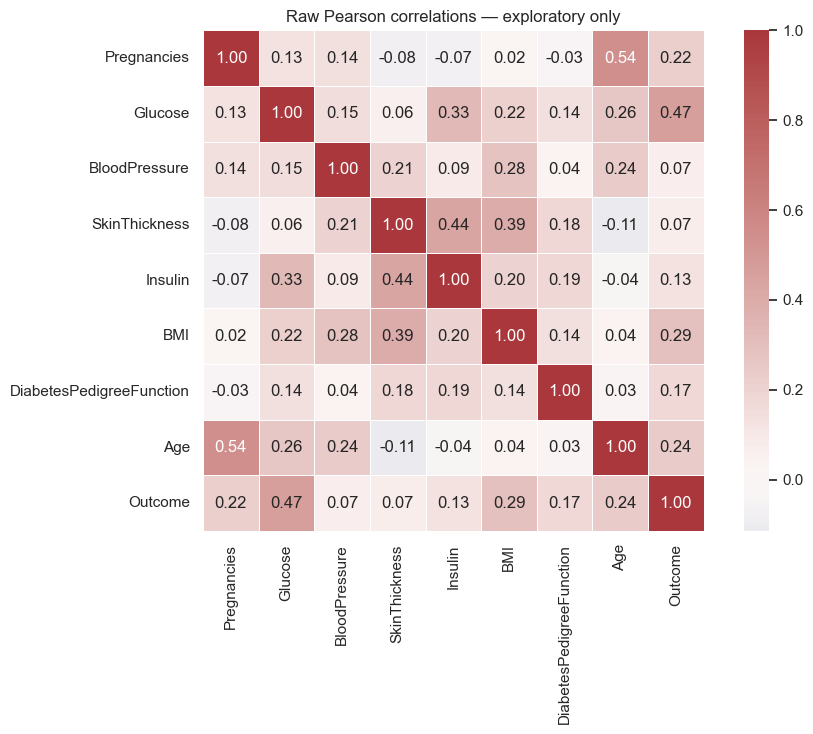

,correlation_with_outcome
Glucose,0.467
BMI,0.293
Age,0.238
Pregnancies,0.222
DiabetesPedigreeFunction,0.174
Insulin,0.131
SkinThickness,0.075
BloodPressure,0.065


In [12]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, linewidths=.5, ax=ax)
ax.set_title("Raw Pearson correlations — exploratory only")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "raw_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

corr["Outcome"].drop("Outcome").sort_values(key=abs, ascending=False).to_frame("correlation_with_outcome")

## 8. Automated validation summary

These assertions turn assumptions into executable checks. Failures should stop downstream work rather than silently contaminating the pipeline.

In [13]:
assert df.shape == (768, 9), f"Unexpected shape: {df.shape}"
assert list(df.columns) == COLUMNS
assert df["Outcome"].isin([0, 1]).all()
assert not df.duplicated().any()
assert raw_sha256 == "6bfe5d0f379d17a0e0819b996407e3c09bf80febd4287f2ed212190dfff154af"

validation = pd.DataFrame([
    ["Expected shape", "PASS", str(df.shape)],
    ["Expected schema", "PASS", f"{len(COLUMNS)} documented columns"],
    ["Binary target", "PASS", str(sorted(df['Outcome'].unique().tolist()))],
    ["No duplicate rows", "PASS", "0 duplicates"],
    ["Pinned raw checksum", "PASS", raw_sha256[:16] + "…"],
    ["Sentinel-zero review", "ATTENTION", f"{int((df[zero_not_valid] == 0).sum().sum())} candidate cells"],
], columns=["Check", "Status", "Evidence"])
validation

,Check,Status,Evidence
0,Expected shape,PASS,"(768, 9)"
1,Expected schema,PASS,9 documented columns
2,Binary target,PASS,"[0, 1]"
3,No duplicate rows,PASS,0 duplicates
4,Pinned raw checksum,PASS,6bfe5d0f379d17a0…
5,Sentinel-zero review,ATTENTION,652 candidate cells


## 9. Findings and decisions for Notebook 02

### What we learned

- The snapshot contains **768 rows and 9 columns**, including a binary outcome.
- There are no literal missing values or exact duplicate rows.
- Several clinical variables contain physiologically implausible zeros. These are likely missing-value sentinels, especially for insulin and skin thickness.
- The target is moderately imbalanced, so accuracy alone will be insufficient.
- Glucose shows the strongest raw linear relationship with outcome; BMI, age, and pregnancies also warrant investigation.
- Insulin and skin thickness are highly skewed and contain many zero sentinels, so raw summary statistics understate the data-quality issue.

### Decisions carried into cleaning

1. Convert invalid zeros to `NaN` only for documented clinical measurement columns—not pregnancies or outcome.
2. Compare median, KNN, and iterative imputation using training-only fitted transformations.
3. Retain a missingness indicator when clinically and statistically justified.
4. Define range checks explicitly; do not delete statistical outliers automatically.
5. Split data before any learned imputation, scaling, resampling, or feature selection to prevent leakage.

### Limitations

- This is a small, historic, population-specific dataset.
- Features are limited and do not represent a complete clinical workup.
- Dataset outcome labels and measurement processes may contain unobserved bias.
- Results must not be generalized without external validation across sites and demographic groups.

In [14]:
artifact_summary = {
    "dataset_rows": len(df),
    "dataset_columns": df.shape[1],
    "positive_cases": int(df["Outcome"].sum()),
    "positive_rate": round(float(df["Outcome"].mean()), 4),
    "candidate_sentinel_zero_cells": int((df[zero_not_valid] == 0).sum().sum()),
    "figures_written": sorted(p.name for p in FIGURE_DIR.glob("*.png")),
}
artifact_summary

{'dataset_rows': 768,
 'dataset_columns': 9,
 'positive_cases': 268,
 'positive_rate': 0.349,
 'candidate_sentinel_zero_cells': 652,
 'figures_written': ['raw_correlation_matrix.png',
  'raw_feature_distributions.png',
  'target_distribution.png']}